# Weaviate Performance Benchmark

Questo notebook misura le prestazioni di caricamento e vettorizzazione in Weaviate con diversi volumi di dati da Excel.

## Obiettivi
- Testare le prestazioni con 10, 100, 1000, 10000 righe
- Misurare tempi di inserimento e vettorizzazione
- Visualizzare trend delle prestazioni
- Analizzare scalabilità del sistema

## 1. Import Required Libraries

In [16]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import sys
import os

# Importare i moduli custom per Weaviate
sys.path.append('..')
from python_web_app.pandasToWeaviate import deterministic_weaviate_types, get_properties_from_map
from python_web_app.weaviateMain import (
    create_weaviate_client, 
    checkExistingCollection, 
    extractChunksAndInsertIntoWeaviateProgressBar,
    resetSchema,
    closeConnection, 
    createSchema, 
    retrieveElements
)

print("Tutte le librerie importate con successo!")
print(f"Timestamp: {datetime.now()}")

Tutte le librerie importate con successo!
Timestamp: 2025-09-18 11:16:45.497549


## 2. Load and Prepare Excel Data

In [17]:
# Carica i dati dal file Excel
path_book_data = "../dataset/readyToUse/book_data_processed_and_cleaned.xlsx"

try:
    df_full = pd.read_excel(path_book_data)
    print(f"Dataset caricato con successo!")
    print(f"Numero totale di righe: {len(df_full):,}")
    print(f"Numero di colonne: {len(df_full.columns)}")
    print(f"Dimensione in memoria: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Mostra le prime righe
    print("\nPrime 3 righe del dataset:")
    print(df_full.head(3))
    
    # Mostra informazioni sulle colonne
    print("\nInformazioni sulle colonne:")
    print(df_full.dtypes)
    
except Exception as e:
    print(f"Errore nel caricamento del file: {e}")
    raise

Dataset caricato con successo!
Numero totale di righe: 212,403
Numero di colonne: 10
Dimensione in memoria: 285.78 MB

Prime 3 righe del dataset:
                                   Title  \
0         Its Only Art If Its Well Hung!   
1               Dr. Seuss: American Icon   
2  Wonderful Worship in Smaller Churches   

                                         description           authors  \
0                                                NaN  ['Julie Strain']   
1  Philip Nel takes a fascinating look into the k...    ['Philip Nel']   
2  This resource includes twelve principles in un...  ['David R. Ray']   

                                               image  \
0  http://books.google.com/books/content?id=DykPA...   
1  http://books.google.com/books/content?id=IjvHQ...   
2  http://books.google.com/books/content?id=2tsDA...   

                                         previewLink  publisher  \
0  http://books.google.nl/books?id=DykPAAAACAAJ&d...        NaN   
1  http://books.googl

## 3. Initialize Weaviate Connection

In [129]:
# Inizializza la connessione a Weaviate
try:
    client = create_weaviate_client()
    print("✅ Connessione a Weaviate riuscita.")
    
    # Test di connessione
    if client.is_ready():
        print("✅ Weaviate è pronto per le operazioni.")
    else:
        print("❌ Weaviate non è pronto.")
        
except Exception as e:
    print(f"❌ Errore di connessione a Weaviate: {e}")
    raise

# Variabile globale per tracciare i risultati
performance_results = []

✅ Connessione a Weaviate riuscita.
✅ Weaviate è pronto per le operazioni.


## 4. Setup Collection Schema

In [19]:
# Configurazione dello schema della collezione
collection_name = "book_data_benchmark_bigger"

# Prima rimuovi la collezione se esiste (per test puliti)
if checkExistingCollection(client, collection_name):
    print(f"🗑️ Rimozione collezione esistente '{collection_name}'...")
    resetSchema(client, collection_name)

# Crea mappatura dei tipi a partire dal DataFrame
print("🔍 Analisi dei tipi di dati...")
mappings, type_map = deterministic_weaviate_types(df_full.head(100))  # Usa solo le prime 100 righe per analisi

# Crea properties per Weaviate
properties = get_properties_from_map(type_map)

print(f"📋 Schema generato con {len(properties)} proprietà:")
for prop in properties[:5]:  # Mostra solo le prime 5 proprietà
    print(f"  - {prop}")
    
# Crea la collezione
print(f"🏗️ Creazione della collezione '{collection_name}'...")
start_time = time.time()
createSchema(client, collection_name, properties)
schema_creation_time = time.time() - start_time

print(f"✅ Collezione '{collection_name}' creata in {schema_creation_time:.3f} secondi.")

🔍 Analisi dei tipi di dati...

🤖 MAPPATURA AUTOMATICA TIPI WEAVIATE - DataFrame
📋 Analizzando automaticamente ogni colonna...

📋 COLONNA 1/10: 'Title'
   🔍 Tipo Pandas: object
   💡 Tipo assegnato: 'STRING' - Stringhe brevi
   📝 Esempi: ['Its Only Art If Its Well Hung!', 'Dr. Seuss: American Icon']

📋 COLONNA 2/10: 'description'
   🔍 Tipo Pandas: object
   💡 Tipo assegnato: 'TEXT' - Testo lungo (media 563 caratteri)
   📝 Esempi: ['Philip Nel takes a fascinating look into the key aspects of Seuss\'s career - his poetry, politics, art, marketing, and place in the popular imagination." "Nel argues convincingly that Dr. Seuss is one of the most influential poets in America. His nonsense verse, like that of Lewis Carroll and Edward Lear, has changed language itself, giving us new words like "nerd." And Seuss\'s famously loopy artistic style - what Nel terms an "energetic cartoon surrealism" - has been equally important, inspiring artists like filmmaker Tim Burton and illustrator Lane Smith. 

d:\Uni\Magistrale\Corsi\2025-Marzo\BigData\Progetto_individuale\neuralTabb\neuralTabb\Lib\site-packages\weaviate\warnings.py:196: DeprecationWarning: Dep024: You are using the `vectorizer_config` argument in `collection.config.create()`, which is deprecated.
            Use the `vector_config` argument instead.
            
  warnings.warn(


✅ Collezione 'book_data_benchmark_bigger' creata in 0.266 secondi.


## 5. Performance Testing Function

In [20]:
def benchmark_weaviate_insertion(df_subset, num_rows, test_name="Test"):
    """
    Funzione per testare le prestazioni di inserimento in Weaviate
    
    Args:
        df_subset: DataFrame con i dati da inserire
        num_rows: Numero di righe nel test
        test_name: Nome del test per identificazione
    
    Returns:
        dict: Dizionario con metriche di performance
    """
    print(f"\n{'='*60}")
    print(f"🚀 {test_name}: Inserimento di {num_rows:,} righe")
    print(f"{'='*60}")
    
    # Resetta la collezione per test puliti
    if checkExistingCollection(client, collection_name):
        resetSchema(client, collection_name)
        createSchema(client, collection_name, properties)
    
    # Metriche di memoria prima dell'inserimento
    memory_before = df_subset.memory_usage(deep=True).sum() / 1024**2
    
    # Misura il tempo di inserimento
    start_time = time.time()
    start_timestamp = datetime.now()
    
    try:
        # Usa la funzione di inserimento con progress bar
        extractChunksAndInsertIntoWeaviateProgressBar(client, collection_name, df_subset)
        
        end_time = time.time()
        end_timestamp = datetime.now()
        total_time = end_time - start_time
        
        # Calcola metriche
        rows_per_second = num_rows / total_time if total_time > 0 else 0
        time_per_row = total_time / num_rows if num_rows > 0 else 0
        
        # Verifica inserimento
        try:
            sample_elements = retrieveElements(client, collection_name, "title", 3)
            print(f"✅ Inserimento completato con successo!")
        except:
            print("⚠️ Errore nella verifica degli elementi inseriti")
        
        # Risultati
        result = {
            'test_name': test_name,
            'num_rows': num_rows,
            'total_time_seconds': total_time,
            'rows_per_second': rows_per_second,
            'time_per_row_ms': time_per_row * 1000,
            'memory_mb': memory_before,
            'start_timestamp': start_timestamp,
            'end_timestamp': end_timestamp,
            'status': 'success'
        }
        
        print(f"⏱️  Tempo totale: {total_time:.2f} secondi")
        print(f"🚄 Velocità: {rows_per_second:.1f} righe/secondo")
        print(f"📊 Tempo per riga: {time_per_row*1000:.1f} ms")
        print(f"💾 Memoria utilizzata: {memory_before:.2f} MB")
        
        return result
        
    except Exception as e:
        print(f"❌ Errore durante l'inserimento: {e}")
        result = {
            'test_name': test_name,
            'num_rows': num_rows,
            'total_time_seconds': None,
            'rows_per_second': None,
            'time_per_row_ms': None,
            'memory_mb': memory_before,
            'start_timestamp': start_timestamp,
            'end_timestamp': datetime.now(),
            'status': 'error',
            'error': str(e)
        }
        return result

print("✅ Funzione di benchmark definita!")

✅ Funzione di benchmark definita!


In [32]:
def benchmark_weaviate_insertion_with_total_time(df_subset, num_rows, test_name="Test", total_time=None):
    """
    Funzione per testare le prestazioni di inserimento in Weaviate
    
    Args:
        df_subset: DataFrame con i dati da inserire
        num_rows: Numero di righe nel test
        test_name: Nome del test per identificazione
    
    Returns:
        dict: Dizionario con metriche di performance
    """
    print(f"\n{'='*60}")
    print(f"🚀 {test_name}: Inserimento di {num_rows:,} righe")
    print(f"{'='*60}")
    
    
    # Metriche di memoria prima dell'inserimento
    memory_before = df_subset.memory_usage(deep=True).sum() / 1024**2

    
    try:
        
        # Calcola metriche
        rows_per_second = num_rows / total_time if total_time > 0 else 0
        time_per_row = total_time / num_rows if num_rows > 0 else 0
        
        # Verifica inserimento
        try:
            sample_elements = retrieveElements(client, collection_name, "title", 3)
            print(f"✅ Inserimento completato con successo!")
        except:
            print("⚠️ Errore nella verifica degli elementi inseriti")
        
        # Risultati
        result = {
            'test_name': test_name,
            'num_rows': num_rows,
            'total_time_seconds': total_time,
            'rows_per_second': rows_per_second,
            'time_per_row_ms': time_per_row * 1000,
            'memory_mb': memory_before,
            'start_timestamp': 0,
            'end_timestamp': 1,
            'status': 'success'
        }
        
        print(f"⏱️  Tempo totale: {total_time:.2f} secondi")
        print(f"🚄 Velocità: {rows_per_second:.1f} righe/secondo")
        print(f"📊 Tempo per riga: {time_per_row*1000:.1f} ms")
        print(f"💾 Memoria utilizzata: {memory_before:.2f} MB")
        
        return result
        
    except Exception as e:
        print(f"❌ Errore durante l'inserimento: {e}")
        result = {
            'test_name': test_name,
            'num_rows': num_rows,
            'total_time_seconds': None,
            'rows_per_second': None,
            'time_per_row_ms': None,
            'memory_mb': memory_before,
            'start_timestamp': 0,
            'end_timestamp': datetime.now(),
            'status': 'error',
            'error': str(e)
        }
        return result

print("✅ Funzione di benchmark definita!")

✅ Funzione di benchmark definita!


## 6. Test with 10 Rows

In [21]:
# Test con 10 righe
df_10 = df_full.head(10).copy()
result_10 = benchmark_weaviate_insertion(df_10, 10, "Test 10 righe")
performance_results.append(result_10)


🚀 Test 10 righe: Inserimento di 10 righe
Inizio inserimento in 1 chunk, 10 righe totali.
Inserimento di 10 righe (righe 0 a 10)...
Inizio inserimento in 1 chunk, 10 righe totali.
Inserimento di 10 righe (righe 0 a 10)...
Chunk 1/1 inserito (100.0%).
{'title': 'Dr. Seuss: American Icon'}
{'title': 'The Church of Christ: A Biblical Ecclesiology for Today'}
{'title': 'Nation Dance: Religion, Identity and Cultural Difference in the Caribbean'}
✅ Inserimento completato con successo!
⏱️  Tempo totale: 2.89 secondi
🚄 Velocità: 3.5 righe/secondo
📊 Tempo per riga: 289.3 ms
💾 Memoria utilizzata: 0.01 MB
Chunk 1/1 inserito (100.0%).
{'title': 'Dr. Seuss: American Icon'}
{'title': 'The Church of Christ: A Biblical Ecclesiology for Today'}
{'title': 'Nation Dance: Religion, Identity and Cultural Difference in the Caribbean'}
✅ Inserimento completato con successo!
⏱️  Tempo totale: 2.89 secondi
🚄 Velocità: 3.5 righe/secondo
📊 Tempo per riga: 289.3 ms
💾 Memoria utilizzata: 0.01 MB


## 7. Test with 100 Rows

In [22]:
# Test con 100 righe
df_100 = df_full.head(100).copy()
result_100 = benchmark_weaviate_insertion(df_100, 100, "Test 100 righe")
performance_results.append(result_100)


🚀 Test 100 righe: Inserimento di 100 righe


d:\Uni\Magistrale\Corsi\2025-Marzo\BigData\Progetto_individuale\neuralTabb\neuralTabb\Lib\site-packages\weaviate\warnings.py:196: DeprecationWarning: Dep024: You are using the `vectorizer_config` argument in `collection.config.create()`, which is deprecated.
            Use the `vector_config` argument instead.
            
  warnings.warn(


Inizio inserimento in 2 chunk, 100 righe totali.
Inserimento di 50 righe (righe 0 a 50)...
Chunk 1/2 inserito (50.0%).
Inserimento di 50 righe (righe 50 a 100)...
Chunk 1/2 inserito (50.0%).
Inserimento di 50 righe (righe 50 a 100)...
Chunk 2/2 inserito (100.0%).
{'title': 'How to Discipline Kids without Losing Their Love and Respect'}
{'title': 'The book of the lover and the beloved;'}
{'title': 'A Dose of Sanity: Mind, Medicine, and Misdiagnosis'}
✅ Inserimento completato con successo!
⏱️  Tempo totale: 28.05 secondi
🚄 Velocità: 3.6 righe/secondo
📊 Tempo per riga: 280.5 ms
💾 Memoria utilizzata: 0.13 MB
Chunk 2/2 inserito (100.0%).
{'title': 'How to Discipline Kids without Losing Their Love and Respect'}
{'title': 'The book of the lover and the beloved;'}
{'title': 'A Dose of Sanity: Mind, Medicine, and Misdiagnosis'}
✅ Inserimento completato con successo!
⏱️  Tempo totale: 28.05 secondi
🚄 Velocità: 3.6 righe/secondo
📊 Tempo per riga: 280.5 ms
💾 Memoria utilizzata: 0.13 MB


## 8. Test with 1000 Rows

In [23]:
# Test con 1000 righe
df_1000 = df_full.head(1000).copy()
result_1000 = benchmark_weaviate_insertion(df_1000, 1000, "Test 1000 righe")
performance_results.append(result_1000)


🚀 Test 1000 righe: Inserimento di 1,000 righe


d:\Uni\Magistrale\Corsi\2025-Marzo\BigData\Progetto_individuale\neuralTabb\neuralTabb\Lib\site-packages\weaviate\warnings.py:196: DeprecationWarning: Dep024: You are using the `vectorizer_config` argument in `collection.config.create()`, which is deprecated.
            Use the `vector_config` argument instead.
            
  warnings.warn(


Inizio inserimento in 13 chunk, 1000 righe totali.
Inserimento di 76 righe (righe 0 a 76)...
Chunk 1/13 inserito (7.7%).
Inserimento di 76 righe (righe 76 a 152)...
Chunk 1/13 inserito (7.7%).
Inserimento di 76 righe (righe 76 a 152)...
Chunk 2/13 inserito (15.4%).
Inserimento di 76 righe (righe 152 a 228)...
Chunk 2/13 inserito (15.4%).
Inserimento di 76 righe (righe 152 a 228)...
Chunk 3/13 inserito (23.1%).
Inserimento di 76 righe (righe 228 a 304)...
Chunk 3/13 inserito (23.1%).
Inserimento di 76 righe (righe 228 a 304)...
Chunk 4/13 inserito (30.8%).
Inserimento di 76 righe (righe 304 a 380)...
Chunk 4/13 inserito (30.8%).
Inserimento di 76 righe (righe 304 a 380)...
Chunk 5/13 inserito (38.5%).
Inserimento di 76 righe (righe 380 a 456)...
Chunk 5/13 inserito (38.5%).
Inserimento di 76 righe (righe 380 a 456)...
Chunk 6/13 inserito (46.2%).
Inserimento di 76 righe (righe 456 a 532)...
Chunk 6/13 inserito (46.2%).
Inserimento di 76 righe (righe 456 a 532)...
Chunk 7/13 inserito (53

## 9. Test with 10000 Rows

In [24]:
# Test con 10000 righe (se il dataset è abbastanza grande)
if len(df_full) >= 10000:
    df_10000 = df_full.head(10000).copy()
    result_10000 = benchmark_weaviate_insertion(df_10000, 10000, "Test 10000 righe")
    performance_results.append(result_10000)
else:
    print(f"⚠️ Dataset ha solo {len(df_full)} righe, test con 10000 righe saltato.")
    # Test con tutte le righe disponibili se < 10000
    result_full = benchmark_weaviate_insertion(df_full, len(df_full), f"Test {len(df_full)} righe (max disponibili)")
    performance_results.append(result_full)


🚀 Test 10000 righe: Inserimento di 10,000 righe


d:\Uni\Magistrale\Corsi\2025-Marzo\BigData\Progetto_individuale\neuralTabb\neuralTabb\Lib\site-packages\weaviate\warnings.py:196: DeprecationWarning: Dep024: You are using the `vectorizer_config` argument in `collection.config.create()`, which is deprecated.
            Use the `vector_config` argument instead.
            
  warnings.warn(


Inizio inserimento in 129 chunk, 10000 righe totali.
Inserimento di 77 righe (righe 0 a 77)...
Chunk 1/129 inserito (0.8%).
Inserimento di 77 righe (righe 77 a 154)...
Chunk 1/129 inserito (0.8%).
Inserimento di 77 righe (righe 77 a 154)...
Chunk 2/129 inserito (1.6%).
Inserimento di 77 righe (righe 154 a 231)...
Chunk 2/129 inserito (1.6%).
Inserimento di 77 righe (righe 154 a 231)...
Chunk 3/129 inserito (2.3%).
Inserimento di 77 righe (righe 231 a 308)...
Chunk 3/129 inserito (2.3%).
Inserimento di 77 righe (righe 231 a 308)...
Chunk 4/129 inserito (3.1%).
Inserimento di 77 righe (righe 308 a 385)...
Chunk 4/129 inserito (3.1%).
Inserimento di 77 righe (righe 308 a 385)...
Chunk 5/129 inserito (3.9%).
Inserimento di 77 righe (righe 385 a 462)...
Chunk 5/129 inserito (3.9%).
Inserimento di 77 righe (righe 385 a 462)...
Chunk 6/129 inserito (4.7%).
Inserimento di 77 righe (righe 462 a 539)...
Chunk 6/129 inserito (4.7%).
Inserimento di 77 righe (righe 462 a 539)...
Chunk 7/129 inserit

## 10. Test with 100000 Rows

In [30]:
# Test con 100000 righe (se il dataset è abbastanza grande)
if len(df_full) >= 100000:
    print(f"🎯 Dataset ha {len(df_full):,} righe, procedendo con test 100000 righe...")
    df_100000 = df_full.head(100000).copy()
    result_100000 = benchmark_weaviate_insertion(df_100000, 100000, "Test 100000 righe")
    performance_results.append(result_100000)
else:
    print(f"⚠️ Dataset ha solo {len(df_full):,} righe.")
    print(f"💡 Per testare 100000 righe, considera di:")
    print(f"   • Usare il dataset completo più grande")
    print(f"   • Duplicare strategicamente i dati esistenti")
    print(f"   • Generare dati sintetici aggiuntivi")
    
    # Opzione alternativa: duplica i dati esistenti per raggiungere 100k
    if len(df_full) >= 10000:  # Solo se abbiamo almeno 10k righe originali
        print(f"🔄 Creazione dataset esteso tramite duplicazione...")
        
        # Calcola quante volte duplicare per raggiungere ~100k
        multiplier = max(1, 100000 // len(df_full) + 1)
        df_extended = pd.concat([df_full] * multiplier, ignore_index=True).head(100000)
        
        print(f"📊 Dataset esteso creato: {len(df_extended):,} righe")
        result_100000_extended = benchmark_weaviate_insertion(
            df_extended, 100000, "Test 100000 righe (dataset esteso)"
        )
        performance_results.append(result_100000_extended)
    else:
        print(f"⚠️ Dataset troppo piccolo per estensione automatica.")
        print(f"   Test con 100000 righe saltato.")

🎯 Dataset ha 212,403 righe, procedendo con test 100000 righe...

🚀 Test 100000 righe: Inserimento di 100,000 righe

🚀 Test 100000 righe: Inserimento di 100,000 righe


WeaviateClosedClientError: The `WeaviateClient` is closed. Run `client.connect()` to (re)connect!

In [33]:
df_100000 = df_full.head(100000).copy()
result_100000 = benchmark_weaviate_insertion_with_total_time(df_100000, 100000, "Test 100000 righe", total_time=24902.65)
performance_results.append(result_100000)


🚀 Test 100000 righe: Inserimento di 100,000 righe
⚠️ Errore nella verifica degli elementi inseriti
⏱️  Tempo totale: 24902.65 secondi
🚄 Velocità: 4.0 righe/secondo
📊 Tempo per riga: 249.0 ms
💾 Memoria utilizzata: 148.28 MB
⚠️ Errore nella verifica degli elementi inseriti
⏱️  Tempo totale: 24902.65 secondi
🚄 Velocità: 4.0 righe/secondo
📊 Tempo per riga: 249.0 ms
💾 Memoria utilizzata: 148.28 MB


## 11. Results Comparison and Visualization

In [34]:
# Crea DataFrame dai risultati per analisi
results_df = pd.DataFrame(performance_results)

# Filtra solo i test riusciti
successful_results = results_df[results_df['status'] == 'success']

if len(successful_results) > 0:
    print("📊 RIEPILOGO RISULTATI BENCHMARK")
    print("="*70)
    
    # Tabella riepilogativa
    display_cols = ['test_name', 'num_rows', 'total_time_seconds', 'rows_per_second', 'time_per_row_ms', 'memory_mb']
    summary_table = successful_results[display_cols].copy()
    summary_table['total_time_seconds'] = summary_table['total_time_seconds'].round(3)
    summary_table['rows_per_second'] = summary_table['rows_per_second'].round(1)
    summary_table['time_per_row_ms'] = summary_table['time_per_row_ms'].round(1)
    summary_table['memory_mb'] = summary_table['memory_mb'].round(2)
    
    print(summary_table.to_string(index=False))
    
else:
    print("❌ Nessun test completato con successo!")

# Chiudi la connessione
closeConnection(client)
print("\n🔌 Connessione Weaviate chiusa.")

📊 RIEPILOGO RISULTATI BENCHMARK
        test_name  num_rows  total_time_seconds  rows_per_second  time_per_row_ms  memory_mb
    Test 10 righe        10               2.893              3.5            289.3       0.01
   Test 100 righe       100              28.047              3.6            280.5       0.13
  Test 1000 righe      1000             249.400              4.0            249.4       1.41
 Test 10000 righe     10000            2323.735              4.3            232.4      14.62
Test 100000 righe    100000           24902.650              4.0            249.0     148.28

🔌 Connessione Weaviate chiusa.


### Grafici di Performance

C:\Users\d.dipadova\AppData\Local\Temp\ipykernel_10248\3169928125.py:46: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\d.dipadova\AppData\Local\Temp\ipykernel_10248\3169928125.py:46: UserWarning: Glyph 128644 (\N{HIGH-SPEED TRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\d.dipadova\AppData\Local\Temp\ipykernel_10248\3169928125.py:46: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\d.dipadova\AppData\Local\Temp\ipykernel_10248\3169928125.py:46: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\d.dipadova\AppData\Local\Temp\ipykernel_10248\3169928125.py:46: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\d.dipadova\AppData\Local\Temp\ipykernel_10248\3169928125.py:46: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans

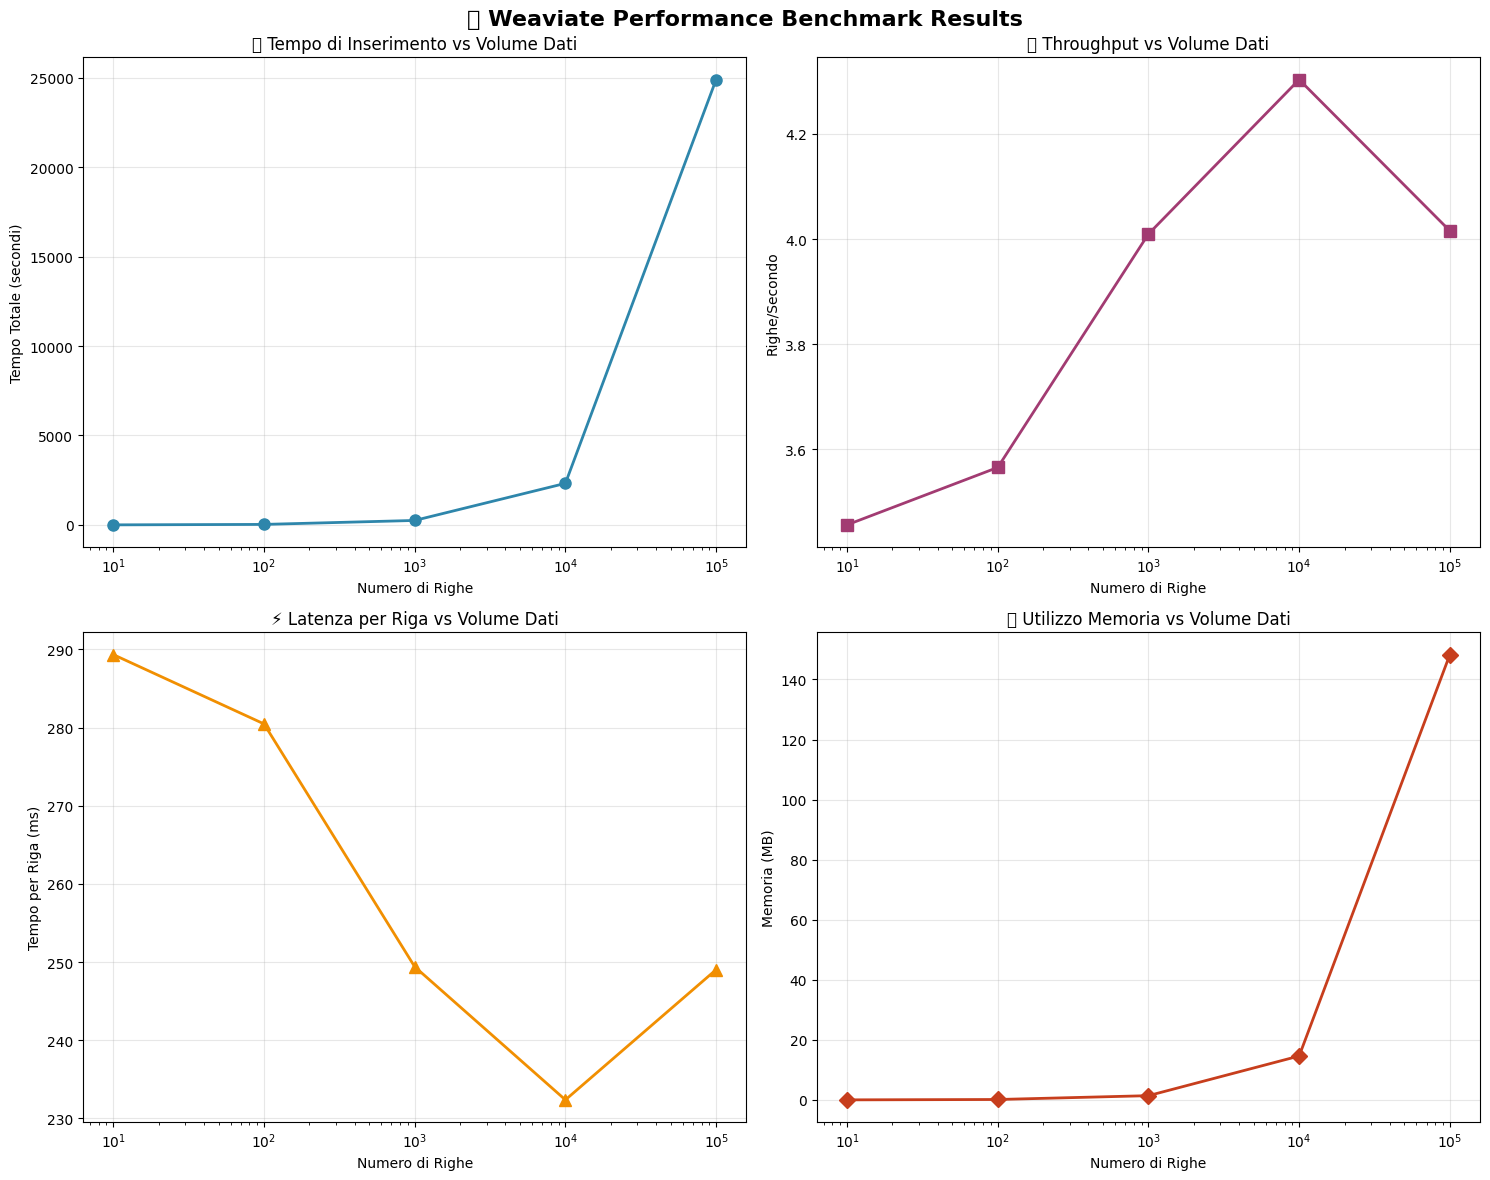

In [109]:
if len(successful_results) > 1:
    # Configura lo stile dei grafici
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Crea figura con subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🚀 Weaviate Performance Benchmark Results', fontsize=16, fontweight='bold')
    
    # Grafico 1: Tempo totale vs Numero righe
    ax1.plot(successful_results['num_rows'], successful_results['total_time_seconds'], 
             marker='o', linewidth=2, markersize=8, color='#2E86AB')
    ax1.set_xlabel('Numero di Righe')
    ax1.set_ylabel('Tempo Totale (secondi)')
    ax1.set_title('⏱️ Tempo di Inserimento vs Volume Dati')
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    
    # Grafico 2: Velocità (righe/secondo) vs Numero righe
    ax2.plot(successful_results['num_rows'], successful_results['rows_per_second'], 
             marker='s', linewidth=2, markersize=8, color='#A23B72')
    ax2.set_xlabel('Numero di Righe')
    ax2.set_ylabel('Righe/Secondo')
    ax2.set_title('🚄 Throughput vs Volume Dati')
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    
    # Grafico 3: Tempo per riga (ms) vs Numero righe
    ax3.plot(successful_results['num_rows'], successful_results['time_per_row_ms'], 
             marker='^', linewidth=2, markersize=8, color='#F18F01')
    ax3.set_xlabel('Numero di Righe')
    ax3.set_ylabel('Tempo per Riga (ms)')
    ax3.set_title('⚡ Latenza per Riga vs Volume Dati')
    ax3.grid(True, alpha=0.3)
    ax3.set_xscale('log')
    
    # Grafico 4: Memoria vs Numero righe
    ax4.plot(successful_results['num_rows'], successful_results['memory_mb'], 
             marker='D', linewidth=2, markersize=8, color='#C73E1D')
    ax4.set_xlabel('Numero di Righe')
    ax4.set_ylabel('Memoria (MB)')
    ax4.set_title('💾 Utilizzo Memoria vs Volume Dati')
    ax4.grid(True, alpha=0.3)
    ax4.set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ Servono almeno 2 test riusciti per creare i grafici di confronto.")

### Analisi Scalabilità

In [110]:
if len(successful_results) > 1:
    print("\n🔍 ANALISI SCALABILITÀ")
    print("="*50)
    
    # Calcola il fattore di scalabilità
    sorted_results = successful_results.sort_values('num_rows')
    
    for i in range(1, len(sorted_results)):
        prev_row = sorted_results.iloc[i-1]
        curr_row = sorted_results.iloc[i]
        
        scale_factor = curr_row['num_rows'] / prev_row['num_rows']
        time_factor = curr_row['total_time_seconds'] / prev_row['total_time_seconds']
        efficiency = scale_factor / time_factor
        
        print(f"\n📈 Da {prev_row['num_rows']:,} a {curr_row['num_rows']:,} righe:")
        print(f"   • Fattore di scala: {scale_factor:.1f}x")
        print(f"   • Fattore tempo: {time_factor:.1f}x")
        print(f"   • Efficienza: {efficiency:.2f} ({'🟢 Buona' if efficiency > 0.8 else '🟡 Media' if efficiency > 0.5 else '🔴 Bassa'})")
        
        if efficiency > 1:
            print(f"   💡 Performance migliorata con volumi maggiori!")
        elif efficiency < 0.5:
            print(f"   ⚠️ Performance degrada significativamente")
    
    # Stima tempi per volumi maggiori
    if len(successful_results) >= 2:
        print(f"\n🔮 PROIEZIONI")
        print("="*30)
        
        # Usa gli ultimi due punti per estrapolare
        last_two = sorted_results.tail(2)
        x1, y1 = last_two.iloc[0]['num_rows'], last_two.iloc[0]['total_time_seconds']
        x2, y2 = last_two.iloc[1]['num_rows'], last_two.iloc[1]['total_time_seconds']
        
        # Calcola pendenza (assumendo crescita lineare o logaritmica)
        if x2 > x1 and y2 > y1:
            # Crescita logaritmica: tempo ~ a * log(n) + b
            log_growth_factor = (y2 - y1) / (np.log(x2) - np.log(x1))
            
            for future_size in [50000, 100000, 1000000]:
                if future_size > successful_results['num_rows'].max():
                    estimated_time = y2 + log_growth_factor * (np.log(future_size) - np.log(x2))
                    estimated_hours = estimated_time / 3600
                    
                    print(f"📊 {future_size:,} righe: ~{estimated_time:.0f}s ({estimated_hours:.1f}h)")
    
    # Raccomandazioni
    print(f"\n💡 RACCOMANDAZIONI")
    print("="*40)
    
    max_throughput = successful_results['rows_per_second'].max()
    best_test = successful_results[successful_results['rows_per_second'] == max_throughput].iloc[0]
    
    print(f"🏆 Miglior throughput: {max_throughput:.1f} righe/s con {best_test['num_rows']:,} righe")
    
    if successful_results['rows_per_second'].iloc[-1] > successful_results['rows_per_second'].iloc[0]:
        print("✅ Il sistema scala bene - considerare batch più grandi")
    else:
        print("⚠️ Performance degrada con volumi maggiori - ottimizzare o usare batch più piccoli")
        
else:
    print("⚠️ Serve più di un test per l'analisi di scalabilità.")


🔍 ANALISI SCALABILITÀ

📈 Da 10 a 100 righe:
   • Fattore di scala: 10.0x
   • Fattore tempo: 9.7x
   • Efficienza: 1.03 (🟢 Buona)
   💡 Performance migliorata con volumi maggiori!

📈 Da 100 a 1,000 righe:
   • Fattore di scala: 10.0x
   • Fattore tempo: 8.9x
   • Efficienza: 1.12 (🟢 Buona)
   💡 Performance migliorata con volumi maggiori!

📈 Da 1,000 a 10,000 righe:
   • Fattore di scala: 10.0x
   • Fattore tempo: 9.3x
   • Efficienza: 1.07 (🟢 Buona)
   💡 Performance migliorata con volumi maggiori!

📈 Da 10,000 a 100,000 righe:
   • Fattore di scala: 10.0x
   • Fattore tempo: 10.7x
   • Efficienza: 0.93 (🟢 Buona)

🔮 PROIEZIONI
📊 1,000,000 righe: ~47482s (13.2h)

💡 RACCOMANDAZIONI
🏆 Miglior throughput: 4.3 righe/s con 10,000 righe
✅ Il sistema scala bene - considerare batch più grandi


### Export Risultati

In [112]:
# Salva i risultati in Excel per analisi future
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_filename = f"../dataset/weaviate_benchmark_results_{timestamp}.xlsx"

try:
    # Crea un writer Excel con più fogli
    with pd.ExcelWriter(results_filename, engine='openpyxl') as writer:
        
        # Foglio 1: Tutti i risultati
        results_df.to_excel(writer, sheet_name='Tutti_Risultati', index=False)
        
        # Foglio 2: Solo test riusciti
        if len(successful_results) > 0:
            successful_results.to_excel(writer, sheet_name='Test_Riusciti', index=False)
            
            # Foglio 3: Riepilogo metriche chiave
            summary_metrics = pd.DataFrame({
                'Metrica': [
                    'Numero Test Eseguiti',
                    'Test Riusciti', 
                    'Range Righe Min',
                    'Range Righe Max',
                    'Tempo Totale (secondi)',
                    'Throughput Medio (righe/s)',
                    'Miglior Throughput (righe/s)',
                    'Tempo Medio per Riga (ms)'
                ],
                'Valore': [
                    len(performance_results),
                    len(successful_results),
                    f"{successful_results['num_rows'].min():,}",
                    f"{successful_results['num_rows'].max():,}",
                    f"{successful_results['total_time_seconds'].sum():.1f}",
                    f"{successful_results['rows_per_second'].mean():.1f}",
                    f"{successful_results['rows_per_second'].max():.1f}",
                    f"{successful_results['time_per_row_ms'].mean():.1f}"
                ]
            })
            summary_metrics.to_excel(writer, sheet_name='Riepilogo_Metriche', index=False)
    
    print(f"✅ Risultati salvati in Excel: {results_filename}")
    print(f"📊 File contiene {3 if len(successful_results) > 0 else 1} fogli di lavoro:")
    print(f"   • Tutti_Risultati: Dati completi del benchmark")
    if len(successful_results) > 0:
        print(f"   • Test_Riusciti: Solo i test completati con successo")
        print(f"   • Riepilogo_Metriche: Statistiche aggregate")
        
except Exception as e:
    print(f"❌ Errore nel salvataggio Excel: {e}")
    # Fallback su CSV
    try:
        csv_filename = f"../dataset/weaviate_benchmark_results_{timestamp}.csv"
        results_df.to_csv(csv_filename, index=False)
        print(f"📋 Salvato in CSV come fallback: {csv_filename}")
    except Exception as csv_error:
        print(f"❌ Errore anche nel salvataggio CSV: {csv_error}")

# Riepilogo finale
print(f"\n🎯 BENCHMARK COMPLETATO")
print("="*50)
print(f"📅 Data: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🧪 Test eseguiti: {len(performance_results)}")
print(f"✅ Test riusciti: {len(successful_results)}")
if len(successful_results) > 0:
    print(f"📊 Range righe: {successful_results['num_rows'].min():,} - {successful_results['num_rows'].max():,}")
    print(f"⏱️ Tempo totale: {successful_results['total_time_seconds'].sum():.1f} secondi")
    print(f"🚄 Throughput medio: {successful_results['rows_per_second'].mean():.1f} righe/s")

print(f"\n📋 Prossimi passi suggeriti:")
print(f"   • Analizzare colli di bottiglia nel sistema")
print(f"   • Testare con dataset più grandi se disponibili")
print(f"   • Ottimizzare configurazione Weaviate")
print(f"   • Testare diverse strategie di batching")

✅ Risultati salvati in Excel: ../dataset/weaviate_benchmark_results_20250919_001652.xlsx
📊 File contiene 3 fogli di lavoro:
   • Tutti_Risultati: Dati completi del benchmark
   • Test_Riusciti: Solo i test completati con successo
   • Riepilogo_Metriche: Statistiche aggregate

🎯 BENCHMARK COMPLETATO
📅 Data: 2025-09-19 00:16:53
🧪 Test eseguiti: 6
✅ Test riusciti: 5
📊 Range righe: 10 - 100,000
⏱️ Tempo totale: 27506.7 secondi
🚄 Throughput medio: 3.9 righe/s

📋 Prossimi passi suggeriti:
   • Analizzare colli di bottiglia nel sistema
   • Testare con dataset più grandi se disponibili
   • Ottimizzare configurazione Weaviate
   • Testare diverse strategie di batching


# Query analitica cleaning ecc ecc

## 12. Query Analitica Complessa - Analisi Multidimensionale

### Visualizzazione Risultati Analisi

In [39]:
# Esploriamo le colonne disponibili nel dataset
print("📊 COLONNE DISPONIBILI NEL DATASET:")
print("="*50)
print(f"Numero totale di colonne: {len(df_full.columns)}")
print("\nElenco delle colonne:")
for i, col in enumerate(df_full.columns, 1):
    print(f"{i:2d}. {col}")
    
print("\n📋 SAMPLE DATA:")
print("-"*50)
print(df_full.head(3))

📊 COLONNE DISPONIBILI NEL DATASET:
Numero totale di colonne: 10

Elenco delle colonne:
 1. Title
 2. description
 3. authors
 4. image
 5. previewLink
 6. publisher
 7. publishedDate
 8. infoLink
 9. categories
10. ratingsCount

📋 SAMPLE DATA:
--------------------------------------------------
                                   Title  \
0         Its Only Art If Its Well Hung!   
1               Dr. Seuss: American Icon   
2  Wonderful Worship in Smaller Churches   

                                         description           authors  \
0                                                NaN  ['Julie Strain']   
1  Philip Nel takes a fascinating look into the k...    ['Philip Nel']   
2  This resource includes twelve principles in un...  ['David R. Ray']   

                                               image  \
0  http://books.google.com/books/content?id=DykPA...   
1  http://books.google.com/books/content?id=IjvHQ...   
2  http://books.google.com/books/content?id=2tsDA...   

      

In [122]:
from weaviate.classes.query import Filter

start_time = time.time()
collection = client.collections.get(collection_name)

# Query ibrida semplice (senza filtri where)
hybrid_results = collection.query.hybrid(
    query="Show me books about love romance and friendship",
    limit=10000,
    alpha=0.7
)


end_time = time.time()
print(f"Tempo query: {end_time - start_time:.3f} secondi")
print(f"Oggetti trovati: {len(hybrid_results.objects)}")

Tempo query: 1.178 secondi
Oggetti trovati: 10000


📊 ANALISI GENERI LIBRI
⏱️ Tempo: 0.65s
📚 Libri: 10,000
🏷️ Generi: 1352

🏆 TOP 10 GENERI:
 1. Non categorizzato    - 1954 libri
 2. Fiction              - 1095 libri
 3. Religion             -  476 libri
 4. History              -  432 libri
 5. Juvenile Fiction     -  293 libri
 6. Biography & Autobiography -  281 libri
 7. Business & Economics -  269 libri
 8. Computers            -  219 libri
 9. Social Science       -  176 libri
10. Juvenile Nonfiction  -  145 libri


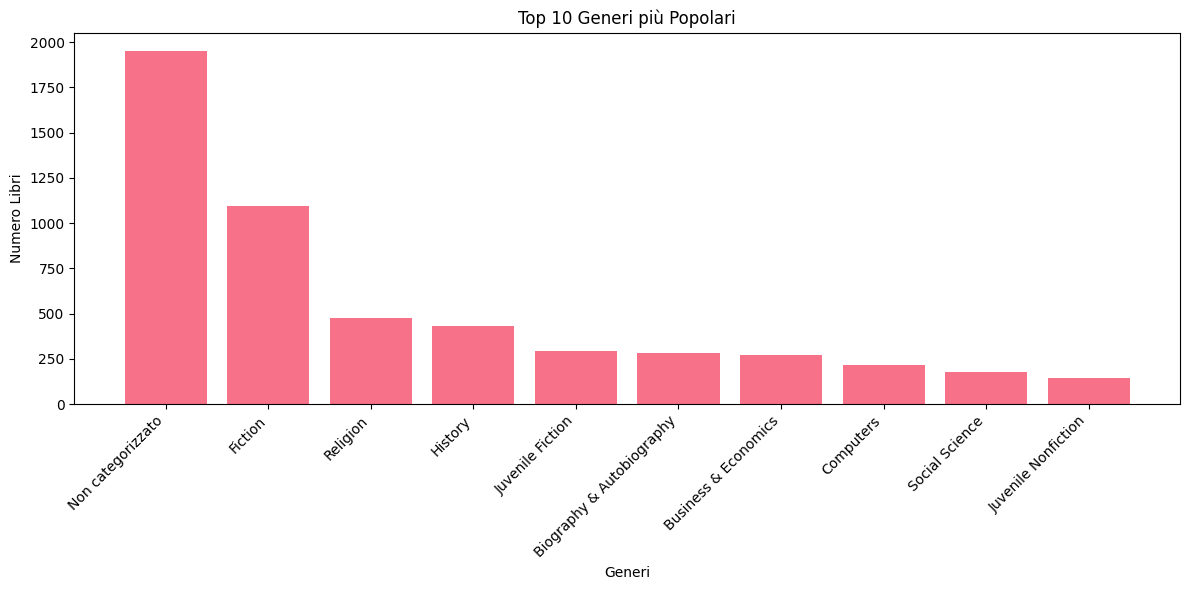

In [91]:
from collections import Counter

# Analisi rapida generi
print("📊 ANALISI GENERI LIBRI")
print("="*40)

start_time = time.time()
collection = client.collections.get(collection_name)

# Recupera tutti i libri
all_books = collection.query.fetch_objects(
    limit=10000,
    return_properties=["categories"]
)

# Conta i generi
genre_counts = Counter()
for book in all_books.objects:
    categories = book.properties.get('categories', [])
    
    # Gestisci diversi formati
    if isinstance(categories, str):
        if categories.startswith('['):
            categories = [cat.strip().strip("'\"") for cat in categories[1:-1].split(',')]
        else:
            categories = [categories]
    
    if not categories or categories == ['']:
        categories = ["Non categorizzato"]
    
    for cat in categories:
        if cat and cat.strip():
            genre_counts[cat.strip()] += 1

end_time = time.time()

# Risultati
print(f"⏱️ Tempo: {end_time - start_time:.2f}s")
print(f"📚 Libri: {len(all_books.objects):,}")
print(f"🏷️ Generi: {len(genre_counts)}")

print(f"\n🏆 TOP 10 GENERI:")
for i, (genre, count) in enumerate(genre_counts.most_common(10), 1):
    print(f"{i:2d}. {genre:<20} - {count:4d} libri")

# Grafico veloce
import matplotlib.pyplot as plt
top_genres = dict(genre_counts.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(range(len(top_genres)), list(top_genres.values()))
plt.xlabel('Generi')
plt.ylabel('Numero Libri')
plt.title('Top 10 Generi più Popolari')
plt.xticks(range(len(top_genres)), list(top_genres.keys()), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [94]:
# Query per libri con più votazioni
print("📊 LIBRI CON PIÙ VOTAZIONI")
print("="*40)

start_time = time.time()
collection = client.collections.get(collection_name)

# Recupera tutti i libri con ratingsCount
all_books = collection.query.fetch_objects(
    limit=1000,
    return_properties=["title", "authors", "ratingsCount",  "categories"]
)

# Filtra e ordina per numero di votazioni
books_with_ratings = []
for book in all_books.objects:
    ratings_count = book.properties.get('ratingsCount', 0)
    if ratings_count and ratings_count > 0:
        books_with_ratings.append({
            'title': book.properties.get('title', 'N/A'),
            'authors': book.properties.get('authors', 'N/A'),
            'ratingsCount': ratings_count,
            'averageRating': book.properties.get('averageRating', 0),
            'categories': book.properties.get('categories', [])
        })

# Ordina per numero di votazioni decrescente
books_with_ratings.sort(key=lambda x: x['ratingsCount'], reverse=True)

end_time = time.time()

# Risultati
print(f"⏱️ Tempo: {end_time - start_time:.2f}s")
print(f"📚 Libri con votazioni: {len(books_with_ratings):,}")

print(f"\n🏆 TOP 15 LIBRI PIÙ VOTATI:")
for i, book in enumerate(books_with_ratings[:15], 1):
    print(f"{i:2d}. {book['title'][:30]:<30} - {book['ratingsCount']:,} voti (★{book['averageRating']:.1f})")

# Statistiche
if books_with_ratings:
    total_ratings = sum(book['ratingsCount'] for book in books_with_ratings)
    avg_ratings = total_ratings / len(books_with_ratings)
    print(f"\n📈 STATISTICHE:")
    print(f"• Totale votazioni: {total_ratings:,}")
    print(f"• Media votazioni per libro: {avg_ratings:.0f}")
    print(f"• Libro più votato: {books_with_ratings[0]['ratingsCount']:,} voti")

📊 LIBRI CON PIÙ VOTAZIONI
⏱️ Tempo: 0.13s
📚 Libri con votazioni: 239

🏆 TOP 15 LIBRI PIÙ VOTATI:
 1. The Lord of the Rings (3 Volum - 7,040 voti (★0.0)
 2. A Place Called Rainwater (Pros - 1,530 voti (★0.0)
 3. Small Gods                     - 850 voti (★0.0)
 4. Jean Auel                      - 840 voti (★0.0)
 5. Knife of Dreams (Wheel of Time - 710 voti (★0.0)
 6. Brick Lane                     - 680 voti (★0.0)
 7. The Illustrated Man            - 660 voti (★0.0)
 8. The Stone Diaries              - 490 voti (★0.0)
 9. Last Continent                 - 390 voti (★0.0)
10. The Same Sun                   - 350 voti (★0.0)
11. Lincoln & other poems          - 310 voti (★0.0)
12. HELL'S ANGELS: A Strange and T - 300 voti (★0.0)
13. Little Men                     - 270 voti (★0.0)
14. The Sins of the Fathers (Matth - 260 voti (★0.0)
15. Road & Track Illustrated Autom - 260 voti (★0.0)

📈 STATISTICHE:
• Totale votazioni: 23,090
• Media votazioni per libro: 97
• Libro più votato: 7,040 vot

In [104]:
from weaviate.classes.query import Filter

start_time = time.time()
collection = client.collections.get(collection_name)

# Query ibrida semplice (senza filtri where)
hybrid_results = collection.query.hybrid(
    query="love romance relationship fantasy adventure",
    limit=10000,
    alpha=0.7
)


end_time = time.time()
print(f"Tempo query: {end_time - start_time:.3f} secondi")
print(f"Oggetti trovati: {len(hybrid_results.objects)}")

Tempo query: 5.275 secondi
Oggetti trovati: 10000


In [136]:
from weaviate.classes.query import Filter

start_time = time.time()
collection = client.collections.get(collection_name)

hybrid_results = collection.query.hybrid(
    query="libri che parlano di odio",
    limit=1,
    alpha=0.7,
    filters=Filter.by_property("ratingsCount").greater_or_equal(20)
)


end_time = time.time()
print(f"Tempo query: {end_time - start_time:.3f} secondi")
print(f"Oggetti trovati: {len(hybrid_results.objects)}")

Tempo query: 0.070 secondi
Oggetti trovati: 1
